# Fine-Tuning vs. Zero-Shot: Does LoRA Fine-Tuning Help on Banking77?

This notebook compares **Qwen2.5-7B-Instruct** zero-shot (no training) against
the same model **fine-tuned with LoRA**, on a single, controlled task:
[Banking77](https://huggingface.co/datasets/mteb/banking77) intent classification
(9,993 training / 3,076 test examples, 77 fine-grained, overlapping intent categories
like `card_not_working` vs. `declined_card_payment`).

**Why this task:** broad topic classification (e.g. news categories) is usually
already close to saturated for a 7B-class instruction model zero-shot -- there's
no real headroom left for fine-tuning to demonstrate. Banking77's categories
overlap heavily by design, which is exactly why it's a standard benchmark for
intent detection: zero-shot prompting has genuine room to fail here.

**What this isolates:** only one variable -- fine-tuning, yes or no -- on the
*same* model, the *same* prompt format (see `src/data.py`), and the *same*
answer-parsing logic (see `src/baseline.py`). No comparison against a different,
larger hosted model (e.g. GPT-4o-mini) is made here deliberately: mixing "model
size/quality" with "fine-tuned or not" would make it impossible to attribute
any accuracy difference to fine-tuning specifically.

**Stack:** Python · Hugging Face `transformers` / `datasets` · PEFT (LoRA) · `trl` (`SFTTrainer`)


In [18]:
import os
import sys
from pathlib import Path

# Locate the project root regardless of where the kernel happened to start
# (e.g. a leftover working directory from an earlier terminal session).
# We walk upward from the current directory until we find the src/ folder
# that ships with this repo -- this works on any machine, not just this one.
cwd = Path.cwd()
project_root = next(p for p in [cwd, *cwd.parents] if (p / "src").is_dir())
os.chdir(project_root)
sys.path.append(str(project_root / "src"))

print(f"Working directory: {os.getcwd()}")


Working directory: /mnt/remote/data/finetune-benchmark


## 1. Dataset

Banking77, loaded and formatted by `src/data.py`. Both the zero-shot baseline
and the fine-tuning run use the exact same prompt built by `build_prompt()`,
so any difference in outcome can't be explained by the two seeing different
question formats.

In [19]:
from data import prepare_dataset

train, test, label_names = prepare_dataset()

print(f"Train examples: {len(train)}")
print(f"Test examples: {len(test)}")
print(f"Intent categories: {len(label_names)}")


Train examples: 9993
Test examples: 3076
Intent categories: 77


## 2. Baseline: Zero-Shot Qwen2.5-7B-Instruct

The control point for the whole experiment. Without this, an accuracy
difference for the fine-tuned model would be uninterpretable -- we wouldn't
know whether it came from fine-tuning, or whether the base model could
already do most of the work through prompting alone.

This runs over the full 3,076-example test set, so it takes a while.

In [ ]:
from baseline import run_baseline

baseline_results = run_baseline()
print(f"\nZero-shot accuracy: {baseline_results['accuracy']:.3f}")


Loading weights: 100%|██████████| 339/339 [00:02<00:00, 136.10it/s]


  100/3076 evaluated
  200/3076 evaluated
  300/3076 evaluated
  400/3076 evaluated
  500/3076 evaluated
  600/3076 evaluated
  700/3076 evaluated
  800/3076 evaluated
  900/3076 evaluated
  1000/3076 evaluated
  1100/3076 evaluated
  1200/3076 evaluated
  1300/3076 evaluated


In [ ]:
import json

Path("results").mkdir(exist_ok=True)
with open("results/baseline.json", "w") as f:
    json.dump(baseline_results, f, indent=2)


In [ ]:
# Free the baseline model's GPU memory before loading another 7B model for training.
import gc
import torch

del baseline_results  # keep the file on disk (already saved above); drop the in-memory copy
gc.collect()
torch.cuda.empty_cache()


## 3. Fine-Tuning with LoRA

LoRA trains a small set of low-rank adapter weights instead of all 7B
parameters -- the base model stays frozen. See `src/train.py` for the
adapter configuration (`LORA_CONFIG`) and training arguments.

This is the slow part of the notebook. If you want to sanity-check the
pipeline first without waiting for a full run, call
`run_lora_finetune(max_steps=5)` instead.

In [ ]:
from train import run_lora_finetune

trainer, adapter_dir = run_lora_finetune()
print(f"\nAdapter saved to {adapter_dir}")


No prebuilt binary for CUDA 12.9, loading CUDA 12.8 instead. Set BNB_CUDA_VERSION to override.
Loading weights: 100%|██████████| 339/339 [00:02<00:00, 148.83it/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.305810
20,0.108902
30,0.083946
40,0.072633
50,0.078883
60,0.076548
70,0.075236
80,0.073313
90,0.071853
100,0.070046



Adapter saved to checkpoints/qwen-banking77-lora


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

{'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 1, 'model.layers.5': 1, 'model.layers.6': 1, 'model.layers.7': 1, 'model.layers.8': 1, 'model.layers.9': 1, 'model.layers.10': 1, 'model.layers.11': 1, 'model.layers.12': 1, 'model.layers.13': 2, 'model.layers.14': 2, 'model.layers.15': 2, 'model.layers.16': 2, 'model.layers.17': 2, 'model.layers.18': 2, 'model.layers.19': 2, 'model.layers.20': 2, 'model.layers.21': 2, 'model.layers.22': 3, 'model.layers.23': 3, 'model.layers.24': 3, 'model.layers.25': 3, 'model.layers.26': 3, 'model.layers.27': 3, 'model.norm': 3, 'model.rotary_emb': 3, 'lm_head': 3}


### Training loss

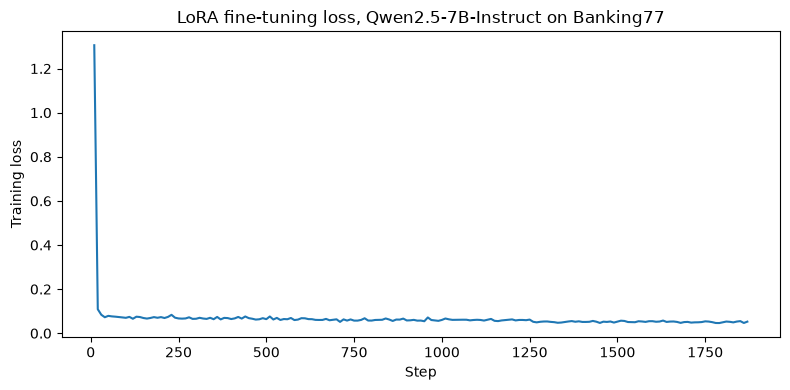

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("LoRA fine-tuning loss, Qwen2.5-7B-Instruct on Banking77")
plt.tight_layout()
plt.savefig("results/training_loss.png", dpi=150)
plt.show()


In [ ]:
# Free the training model's GPU memory before loading the fine-tuned model for evaluation.
del trainer
gc.collect()
torch.cuda.empty_cache()


## 4. Evaluation: Fine-Tuned Model

Runs the same generation and answer-parsing logic as the baseline (imported
from `baseline.py`, not reimplemented), over the same full test set, with
the LoRA adapter applied on top of the base model.

In [ ]:
from evaluate import run_finetuned_eval

finetuned_results = run_finetuned_eval(adapter_dir)
print(f"\nFine-tuned accuracy: {finetuned_results['accuracy']:.3f}")


Loading weights: 100%|██████████| 339/339 [00:02<00:00, 135.04it/s]


  100/3076 evaluated
  200/3076 evaluated
  300/3076 evaluated
  400/3076 evaluated
  500/3076 evaluated
  600/3076 evaluated
  700/3076 evaluated
  800/3076 evaluated
  900/3076 evaluated
  1000/3076 evaluated
  1100/3076 evaluated
  1200/3076 evaluated
  1300/3076 evaluated
  1400/3076 evaluated
  1500/3076 evaluated
  1600/3076 evaluated
  1700/3076 evaluated
  1800/3076 evaluated
  1900/3076 evaluated
  2000/3076 evaluated
  2100/3076 evaluated
  2200/3076 evaluated
  2300/3076 evaluated
  2400/3076 evaluated
  2500/3076 evaluated
  2600/3076 evaluated
  2700/3076 evaluated
  2800/3076 evaluated
  2900/3076 evaluated
  3000/3076 evaluated

Fine-tuned accuracy: 0.887


In [ ]:
with open("results/finetuned.json", "w") as f:
    json.dump(finetuned_results, f, indent=2)


## 5. Comparison

In [ ]:
from evaluate import compare_results

compare_results(Path("results/baseline.json"), Path("results/finetuned.json"))


Metric                  Baseline    Fine-tuned
----------------------------------------------
Accuracy                   0.628         0.887
correct                     1932          2729
wrong_valid                  991           312
invalid_category             153            35
unparseable                    0             0


## 6. Conclusion

LoRA fine-tuning improved accuracy from 62.8% (zero-shot) to 88.7% (fine-tuned), a gain of nearly 26 percentage points on Banking77's 3,076-example test set. Given that both runs used the identical prompt format and answer-parsing logic (see `src/data.py`, `src/baseline.py`), this gain is attributable to the fine-tuning itself, not to a difference in how the two models were asked.

The `invalid_category` count, the model producing a plausible-sounding but nonexistent label instead of one of the 77 allowed categories, dropped from 153 to 35, a 77% reduction. This is a larger relative improvement than the drop in `wrong_valid` errors (991 to 312, a 68% reduction), which suggests fine-tuning helped disproportionately with a specific failure mode: staying within a constrained output set, not just picking a semantically closer category. That distinction wouldn't be visible from accuracy alone, which is why the four-way breakdown in `src/evaluate.py` mattered here, not just a single number.

A per-category error analysis (see the `predictions` list in `results/baseline.json` / `results/finetuned.json`) would be the natural next step to identify which specific intents remained most commonly confused after fine-tuning, not done here, but straightforward to add given the saved per-example records.

The model does not reach perfect accuracy even after fine-tuning, and it is worth being honest about why, rather than assuming more training epochs would simply close the gap. The loss curve above flattens out after roughly 50 steps and stays flat for the remaining ~1,800 steps, which suggests the model had largely converged on the training data well before training ended, not that it was undertrained. More plausible explanations for the remaining errors include genuine ambiguity in Banking77 itself (some of the 77 categories describe closely related situations that even a human agent might reasonably file under either one), a fixed generation length or greedy decoding occasionally cutting off or misreading a borderline case, and the inherent ceiling of a 7B model's language understanding on fine-grained distinctions.